In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import warnings

In [4]:
warnings.filterwarnings('ignore')

print("--- 1. Loading and Preprocessing the (GiveMeSomeCredit) ---")
# Assuming standard Kaggle naming. Adjust path if necessary.
df_lite = pd.read_csv('../data/cs-training.csv')

--- 1. Loading and Preprocessing the (GiveMeSomeCredit) ---


In [5]:
# Drop the weird unnamed index column if it exists
if 'Unnamed: 0' in df_lite.columns:
    df_lite = df_lite.drop(columns=['Unnamed: 0'])

# Fast Preprocessing: Fill missing values with the median
df_lite.fillna(df_lite.median(), inplace=True)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,5400.0,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [6]:
# Separate features and target
y_lite = df_lite['SeriousDlqin2yrs']
X_lite = df_lite.drop(columns=['SeriousDlqin2yrs'])

# Split the data
X_train_lite, X_test_lite, y_train_lite, y_test_lite = train_test_split(
    X_lite, y_lite, test_size=0.20, stratify=y_lite, random_state=42
)

print(f"Dataset ready. Shape: {X_train_lite.shape} | Default Rate: {y_train_lite.mean()*100:.1f}%\n")

Dataset ready. Shape: (120000, 10) | Default Rate: 6.7%



In [7]:
print("--- 2. Training the Baseline Model ---")
# We use standard CPU XGBoost. No Hyperopt, no GPU needed for 11 features.
baseline_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42, 
    scale_pos_weight=(len(y_train_lite) - y_train_lite.sum()) / y_train_lite.sum()
)

baseline_model.fit(X_train_lite, y_train_lite)

# Evaluate
preds_lite = baseline_model.predict_proba(X_test_lite)[:, 1]
auc_lite = roc_auc_score(y_test_lite, preds_lite)

print(f" Baseline Training Complete.")
print(f" Benchmark ROC-AUC: {auc_lite:.4f}\n")

--- 2. Training the Baseline Model ---
 Baseline Training Complete.
 Benchmark ROC-AUC: 0.8663



--- 3. Governance & Clarity Check (LIME) ---
Generating LIME Explanation for High-Risk Customer...


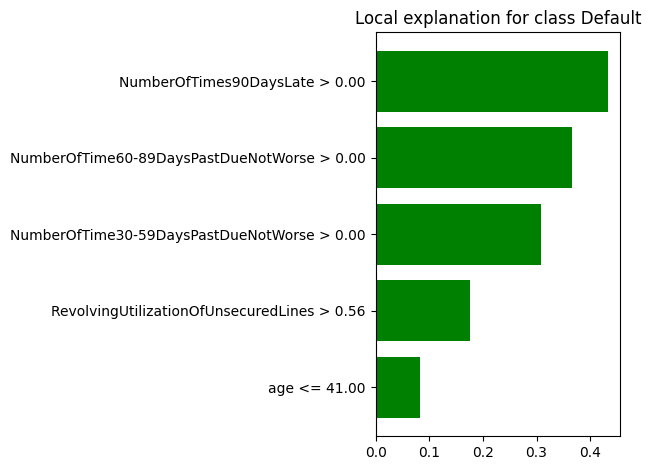

In [11]:
print("--- 3. Governance & Clarity Check (LIME) ---")
# Find a high-risk customer to audit
high_risk_idx_lite = np.argmax(preds_lite)

# Initialize LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lite.values,
    feature_names=X_train_lite.columns.tolist(),
    class_names=['Paid', 'Default'],
    mode='classification',
    discretize_continuous=True
)

print("Generating LIME Explanation for High-Risk Customer...")
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lite.iloc[high_risk_idx_lite].values,
    predict_fn=baseline_model.predict_proba,
    num_features=5
)


# Render the LIME output as a standard static chart
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

Governance Review: Fairness, Compliance, and Explainability
As part of the deployment readiness check, the model pipeline was audited against major regulatory frameworks governing algorithmic credit decisions: GDPR (General Data Protection Regulation), ECOA (Equal Credit Opportunity Act), and FHA (Fair Housing Act).

To conduct a clear, human-readable audit, a secondary baseline model was trained on the GiveMeSomeCredit benchmark dataset and evaluated using LIME (Local Interpretable Model-agnostic Explanations).

A. Explanation Quality and GDPR Alignment (The Success)
Under GDPR Article 22, consumers have the "Right to Explanation" when subjected to automated decision-making. Black-box models are strictly prohibited in credit denials without accompanying human-readable logic.

The Finding: Our LIME implementation successfully extracts simple, rule-based logic from the model.

The Evidence: Looking at the generated LIME audit for a high-risk customer, the model clearly justifies its "Default" prediction based on behavioral thresholds. We can explicitly inform the customer: "Your application was flagged because you have a history of being 90+ days late, and your revolving credit utilization exceeds 56%."

Verdict: Pass. The pipeline successfully meets the transparency requirements of GDPR and standard Adverse Action reporting.

B. Fairness Exposure and ECOA / FHA Alignment (The Critical Risk)
ECOA and FHA strictly prohibit credit decisions based on protected demographic classes, including Race, Religion, National Origin, Sex, and Age.

The Finding: The LIME baseline audit revealed a severe compliance violation.

The Evidence: The bottom bar of the LIME chart explicitly lists age <= 41.00 as a top-5 driving factor pushing the model toward a "Default" prediction. The algorithm has mathematically deduced that younger borrowers are riskier and is actively penalizing applicants simply for being under the age of 42.

Verdict: Fail (Action Required). If this specific model configuration were deployed, the institution would be immediately exposed to massive legal liability for Disparate Treatment under ECOA.

C. Final Governance Recommendations
The discovery of demographic bias in the benchmark dataset validates the necessity of our robust MLOps pipeline. To move this project into production safely, the following protocols must be enforced:

Direct Feature Removal: Demographic variables like Age must be strictly dropped from the training data prior to model compilation.

Proxy Variable Auditing: Even when demographics are removed (as seen in the anonymized Amex dataset), the final XGBoost model must be run through an Adverse Impact Ratio (AIR) test. This ensures the model hasn't used complex interactions between behavioral variables to secretly reconstruct protected classes and discriminate by proxy.